# Southeast Housing Market Analysis

---

## Executive Summary

| | |
|---|---|
| **Objective** | Rank Southeast metros on affordability, income growth, employment strength, and home-price momentum; identify which best balance growth potential with labor-market stability |
| **Data** | U.S. Census ACS 1-year (2019, 2023) · FHFA House Price Index (quarterly) · BLS LAUS (unemployment rate, employment level) |
| **Method** | Three-pillar percentile scoring — Affordability (33%), Growth (34%), Labor Market (33%) — combined into an overall score; geometric mean of Growth and Labor Market produces a Balance score that penalizes one-dimensional strength |
| **Key Finding** | Huntsville, AL is the top-ranked metro on both overall score and balance score. Fayetteville-Springdale-Rogers, AR and Nashville, TN lead the pure balance ranking. Mid-size metros with diverse employment anchors consistently outperform large coastal metros, which are penalized by high price-to-income ratios. |
| **Business Implication** | The strongest value propositions in the Southeast are not the headline markets. Metros with genuine economic infrastructure, tight labor markets, and lower price bases offer better risk-adjusted positioning for buyers, investors, and lenders than high-price, high-growth markets where income has not kept pace with appreciation. |

---

**Research Question:** Which Southeast metros rank highest on affordability, income growth, employment strength, and home-price momentum, and which best balance growth potential with labor-market stability?


## 0. Imports and Setup

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from adjustText import adjust_text
from data_ingestion import build_latest_market_snapshot, load_all_source_tables

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Global chart style — applied to every plot in the notebook.
BLUE = "#2563eb"   # primary accent
RED  = "#dc2626"   # contrast/highlight
GRAY = "#6b7280"   # reference lines and secondary text

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#d1d5db",
    "axes.linewidth": 0.8,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.titlepad": 12,
    "axes.labelsize": 11,
    "axes.labelcolor": "#374151",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": "#e5e7eb",
    "grid.linewidth": 0.6,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.framealpha": 0.9,
    "legend.edgecolor": "#d1d5db",
    "legend.fontsize": 9,
})


In [2]:
import os

# Uncomment and replace with your own key if it is not already set in your environment.
# os.environ["BLS_API_KEY"] = "your_key_here"
print("BLS_API_KEY loaded:", bool(os.getenv("BLS_API_KEY")))

BLS_API_KEY loaded: False


## 1. ETL and Data Sourcing

In [3]:
# Fetched all source tables from the live APIs.
# load_all_source_tables() handles API pulls, caching, type conversion,
# and source-specific cleaning (sentinel replacement, SA/NSA fallback, FIPS fill).
tables = load_all_source_tables(bls_start_year=2020, bls_end_year=2026)

metro_dim_df           = tables["metro_dim_df"]
census_profile_df      = tables["census_profile_df"]
fhfa_df                = tables["fhfa_df"]
bls_df                 = tables["bls_df"]
growth_metrics_df      = tables["growth_metrics_df"]
employment_growth_df   = tables["employment_growth_df"]
building_permits_df    = tables["building_permits_df"]
industry_employment_df = tables["industry_employment_df"]


## 2. Raw Data Inspection

This section checks that each source loaded as expected before any cleaning or scoring starts. One thing to note up front: `industry_employment_df` is optional and not used in the current scoring model, so an empty shape there does not mean the core pipeline failed.

In [4]:
# Printed the shape of each source table to confirm the load completed as expected.
print("metro_dim_df:", metro_dim_df.shape)
print("census_profile_df:", census_profile_df.shape)
print("fhfa_df:", fhfa_df.shape)
print("bls_df:", bls_df.shape)
print("growth_metrics_df:", growth_metrics_df.shape)
print("employment_growth_df:", employment_growth_df.shape)
print("building_permits_df:", building_permits_df.shape)
print("industry_employment_df:", industry_employment_df.shape)


metro_dim_df: (156, 7)
census_profile_df: (156, 23)
fhfa_df: (21828, 10)
bls_df: (7920, 9)
growth_metrics_df: (143, 6)
employment_growth_df: (110, 8)
building_permits_df: (109, 7)
industry_employment_df: (0, 12)


## 3. Data Quality Review

In [5]:
# Counted missing values across each source table to identify columns needing review.
for name, df in [
    ("census_profile_df",      census_profile_df),
    ("fhfa_df",                fhfa_df),
    ("bls_df",                 bls_df),
    ("growth_metrics_df",      growth_metrics_df),
    ("employment_growth_df",   employment_growth_df),
    ("building_permits_df",    building_permits_df),
    ("industry_employment_df", industry_employment_df),
]:
    nulls = df.isnull().sum()
    dups  = df.duplicated().sum()
    print(f"{name}: {nulls[nulls > 0].to_dict() or 'no nulls'} | dupes={dups}")

# Sentinel replacement now happens inside fetch_census_metros() in data_ingestion.py.
# Confirmed here that no -666666666 values remain in the loaded profile table.
sentinel_cols = ["median_home_value", "median_gross_rent", "median_household_income",
                 "population", "housing_units"]
sentinel_hits = {c: (census_profile_df[c] == -666666666).sum() for c in sentinel_cols}
print("\nCensus sentinel counts (all should be 0):", sentinel_hits)


census_profile_df: {'total_renters_grapi': 1, 'cost_burden_rate': 1} | dupes=0
fhfa_df: {'hpi_index_nsa': 4323, 'hpi_index_sa': 4323} | dupes=0
bls_df: {'unemployment_rate': 110} | dupes=0
growth_metrics_df: no nulls | dupes=0
employment_growth_df: no nulls | dupes=0
building_permits_df: no nulls | dupes=0
industry_employment_df: no nulls | dupes=0

Census sentinel counts (all should be 0): {'median_home_value': np.int64(0), 'median_gross_rent': np.int64(0), 'median_household_income': np.int64(0), 'population': np.int64(0), 'housing_units': np.int64(0)}


## 4. Data Cleaning

In [6]:
# Working copies — source-specific cleaning is handled in data_ingestion.py.
# What remains here are analysis-specific filter choices for this research question.
census_clean_df = census_profile_df.copy()
fhfa_clean_df = fhfa_df.copy()
bls_clean_df = bls_df.copy()

# Analysis choice: drop metros where the HPI series has no usable value.
fhfa_clean_df = fhfa_clean_df.dropna(subset=["hpi_index_sa"]).copy()

# Analysis choice: drop metros missing a current unemployment reading.
bls_clean_df = bls_clean_df.dropna(subset=["unemployment_rate"]).copy()

# Build the analysis-ready snapshot. Passes all available source tables;
# build_latest_market_snapshot() merges only the columns it recognises.
market_snapshot_clean_df = build_latest_market_snapshot(
    census_clean_df, fhfa_clean_df, bls_clean_df,
    growth_metrics_df, employment_growth_df,
    building_permits_df, industry_employment_df,
)

print("census_clean_df:", census_clean_df.shape)
print("fhfa_clean_df:", fhfa_clean_df.shape)
print("bls_clean_df:", bls_clean_df.shape)
print("market_snapshot_clean_df:", market_snapshot_clean_df.shape)
print("\nNull counts in market_snapshot_clean_df:")
print(market_snapshot_clean_df.isnull().sum())


census_clean_df: (156, 23)
fhfa_clean_df: (17505, 10)
bls_clean_df: (7810, 9)
market_snapshot_clean_df: (156, 50)

Null counts in market_snapshot_clean_df:
cbsa_code                        0
metro_name                       0
metro_name_full                  0
primary_state_fips               0
state_abbrevs                    0
median_home_value                0
median_gross_rent                0
median_household_income          0
population                       0
median_age                       0
housing_units                    0
vacant_housing_units             0
median_year_built                0
owner_occupied_units             0
renter_occupied_units            0
owner_occupancy_rate             0
renter_occupancy_rate            0
pop_25_plus                      0
college_attainment_rate          0
total_renters_grapi              1
cost_burden_rate                 1
source                           0
pulled_at_utc                    0
latest_hpi_period_end           49
hpi_

In [7]:
# Kept a final analysis table with complete core metrics across all pillars.
analysis_df = market_snapshot_clean_df.dropna(
    subset=[
        "hpi_index_sa",
        "hpi_qoq_pct",
        "hpi_yoy_pct",
        "unemployment_rate",
        "pop_growth_pct",
        "income_growth_pct",
        "employment_yoy_growth_pct",
        "employment_pop_ratio",
        "vacancy_rate",
        "gross_yield",
    ]
).copy()

print("market_snapshot_clean_df:", market_snapshot_clean_df.shape)
print("analysis_df:", analysis_df.shape)
print("\nNull counts in analysis_df:")
print(analysis_df.isnull().sum())

market_snapshot_clean_df: (156, 50)
analysis_df: (105, 50)

Null counts in analysis_df:
cbsa_code                        0
metro_name                       0
metro_name_full                  0
primary_state_fips               0
state_abbrevs                    0
median_home_value                0
median_gross_rent                0
median_household_income          0
population                       0
median_age                       0
housing_units                    0
vacant_housing_units             0
median_year_built                0
owner_occupied_units             0
renter_occupied_units            0
owner_occupancy_rate             0
renter_occupancy_rate            0
pop_25_plus                      0
college_attainment_rate          0
total_renters_grapi              0
cost_burden_rate                 0
source                           0
pulled_at_utc                    0
latest_hpi_period_end            0
hpi_index_sa                     0
hpi_qoq_pct                      0
hp

## 5. Exploratory Data Analysis

In [8]:
# Focused the exploratory analysis on the final complete-case table.
analysis_df.head(10)

,cbsa_code,metro_name,metro_name_full,primary_state_fips,state_abbrevs,median_home_value,median_gross_rent,median_household_income,population,median_age,housing_units,vacant_housing_units,median_year_built,owner_occupied_units,renter_occupied_units,owner_occupancy_rate,renter_occupancy_rate,pop_25_plus,college_attainment_rate,total_renters_grapi,cost_burden_rate,source,pulled_at_utc,latest_hpi_period_end,hpi_index_sa,hpi_qoq_pct,hpi_yoy_pct,latest_unemployment_period,unemployment_rate,pop_growth_pct,income_growth_pct,renter_share_change_pct,employment_level,employment_yoy_growth_pct,employment_pop_ratio,price_to_income_ratio,annual_rent_to_income_ratio,vacancy_rate,gross_yield,permits_total_units,permits_single_family,permits_multifamily_5plus,permits_year,emp_total_nonfarm,emp_manufacturing,emp_financial,emp_professional_business,emp_education_health,emp_leisure_hospitality,emp_government
0,10500,"Albany, GA","Albany, GA Metro Area",13,GA,164100,858,53056,147062,38.30,67256,8028,1983,31494,27734,0.47,0.41,98247,0.21,"27,734.00",0.36,census_acs1_2023,2026-04-16T17:53:06.215542+00:00,2025-12-31,261.28,2.32,6.97,2025-12,4.00,-0.22,30.60,3.90,"59,877.00",0.25,0.41,3.09,0.19,11.94,6.27,183.00,162.00,15.00,"2,023.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10780,"Alexandria, LA","Alexandria, LA Metro Area",22,LA,166700,915,52390,148171,38.50,68078,9843,1983,36464,21771,0.54,0.32,100418,0.21,"21,771.00",0.43,census_acs1_2023,2026-04-16T17:53:06.215542+00:00,2025-12-31,277.19,0.57,-0.39,2025-12,3.70,-2.54,3.63,4.54,"62,629.00",1.47,0.42,3.18,0.21,14.46,6.59,241.00,223.00,0.00,"2,023.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,11500,"Anniston-Oxford, AL","Anniston-Oxford, AL Metro Area",01,AL,160900,782,50780,116429,40.50,53543,7233,1979,31834,14476,0.59,0.27,78420,0.24,"14,476.00",0.40,census_acs1_2023,2026-04-16T17:53:06.215542+00:00,2025-12-31,298.22,0.82,6.96,2025-12,2.50,2.49,5.45,2.46,"49,251.00",2.10,0.42,3.17,0.18,13.51,5.83,64.00,62.00,0.00,"2,023.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,11700,"Asheville, NC","Asheville, NC Metro Area",37,NC,398500,1286,67837,417202,43.90,208385,43628,1990,114432,50325,0.55,0.24,312000,0.45,"50,325.00",0.47,census_acs1_2023,2026-04-16T17:53:06.215542+00:00,2025-12-31,517.65,1.95,-0.90,2025-12,3.20,-9.83,18.13,-5.94,"202,558.00",0.69,0.49,5.87,0.23,20.94,3.87,"3,926.00","2,636.00","1,260.00","2,023.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,12020,"Athens-Clarke County, GA","Athens-Clarke County, GA Metro Area",13,GA,328000,1270,67364,219870,32.80,94301,6666,1992,49083,38552,0.52,0.41,136500,0.47,"38,552.00",0.50,census_acs1_2023,2026-04-16T17:53:06.215542+00:00,2025-12-31,421.10,1.29,2.06,2025-12,3.00,3.37,32.18,-1.51,"106,816.00",0.60,0.49,4.87,0.23,7.07,4.65,"1,026.00",776.00,183.00,"2,023.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,12220,"Auburn-Opelika, AL","Auburn-Opelika, AL Metro Area",01,AL,265600,966,57580,202676,33.90,91863,9928,1996,52554,29381,0.57,0.32,124809,0.40,"29,381.00",0.50,census_acs1_2023,2026-04-16T17:53:06.215542+00:00,2025-12-31,337.37,3.81,3.76,2025-12,2.10,23.18,7.20,9.03,"95,945.00",1.99,0.47,4.61,0.20,10.81,4.36,"1,403.00","1,359.00",5.00,"2,023.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,12260,"Augusta-Richmond County, GA-SC","Augusta-Richmond County, GA-SC Metro Area",13,"GA,SC",238300,1101,67152,628186,38.50,275588,39217,1990,166773,69598,0.61,0.25,428472,0.30,"69,598.00",0.51,census_acs1_2023,2026-04-16T17:53:06.215542+00:00,2025-12-31,325.34,0.00,5.55,2025-12,4.30,2.87,21.78,1.29,"259,677.00",2.03,0.41,3.55,0.20,14.23,5.54,"3,559.00","3,380.00",132.00,"2,023.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,12940,"Baton Rouge, LA","Baton Rouge, LA Metro Area",22,LA,239700,1100,64550,873661,36.80,388100,53698,1991,231880,102522,0.60,0.26,573192,0.29,"102,522.00",0.53,census_acs1_2023,2026-04-16T17:53:06.215542+00:00,2025-12-31,299.44,1.45,4.62,2025-12,3.70,2.20,6.26,2.57,"420,327.00",2.58,0.48,3.71,0.20,13.84,5.51,"3,281.00","3,013.00",264.00,"2,023.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,13820,"Birmingham, AL","Birmingham, AL Metro 

In [9]:
# Reviewed summary statistics for the core metrics across all pillars.
eda_columns = [
    "median_home_value",
    "median_gross_rent",
    "median_household_income",
    "population",
    "price_to_income_ratio",
    "annual_rent_to_income_ratio",
    "gross_yield",
    "vacancy_rate",
    "hpi_qoq_pct",
    "hpi_yoy_pct",
    "pop_growth_pct",
    "unemployment_rate",
    "employment_yoy_growth_pct",
    "income_growth_pct",
]

analysis_df[eda_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
median_home_value,105.00,"273,872.38","81,836.16","160,600.00","213,500.00","248,600.00","320,700.00","595,500.00"
median_gross_rent,105.00,"1,182.95",273.33,758.00,973.00,"1,103.00","1,360.00","2,039.00"
median_household_income,105.00,"66,233.66","10,163.47","49,974.00","58,592.00","64,904.00","72,915.00","96,096.00"
population,105.00,"477,457.29","510,866.12","88,753.00","158,635.00","304,818.00","590,295.00","2,817,933.00"
price_to_income_ratio,105.00,4.08,0.72,2.93,3.55,4.00,4.54,6.61
annual_rent_to_income_ratio,105.00,0.21,0.03,0.14,0.20,0.21,0.23,0.30
gross_yield,105.00,5.31,0.71,3.87,4.74,5.19,5.83,7.15
vacancy_rate,105.00,12.05,5.32,3.33,8.32,10.66,14.33,32.30
hpi_qoq_pct,105.00,0.93,2.21,-3.74,-0.57,0.98,2.32,9.67
hpi_yoy_pct,105.00,3.05,2.81,-9.30,1.82,3.22,4.34,9.19


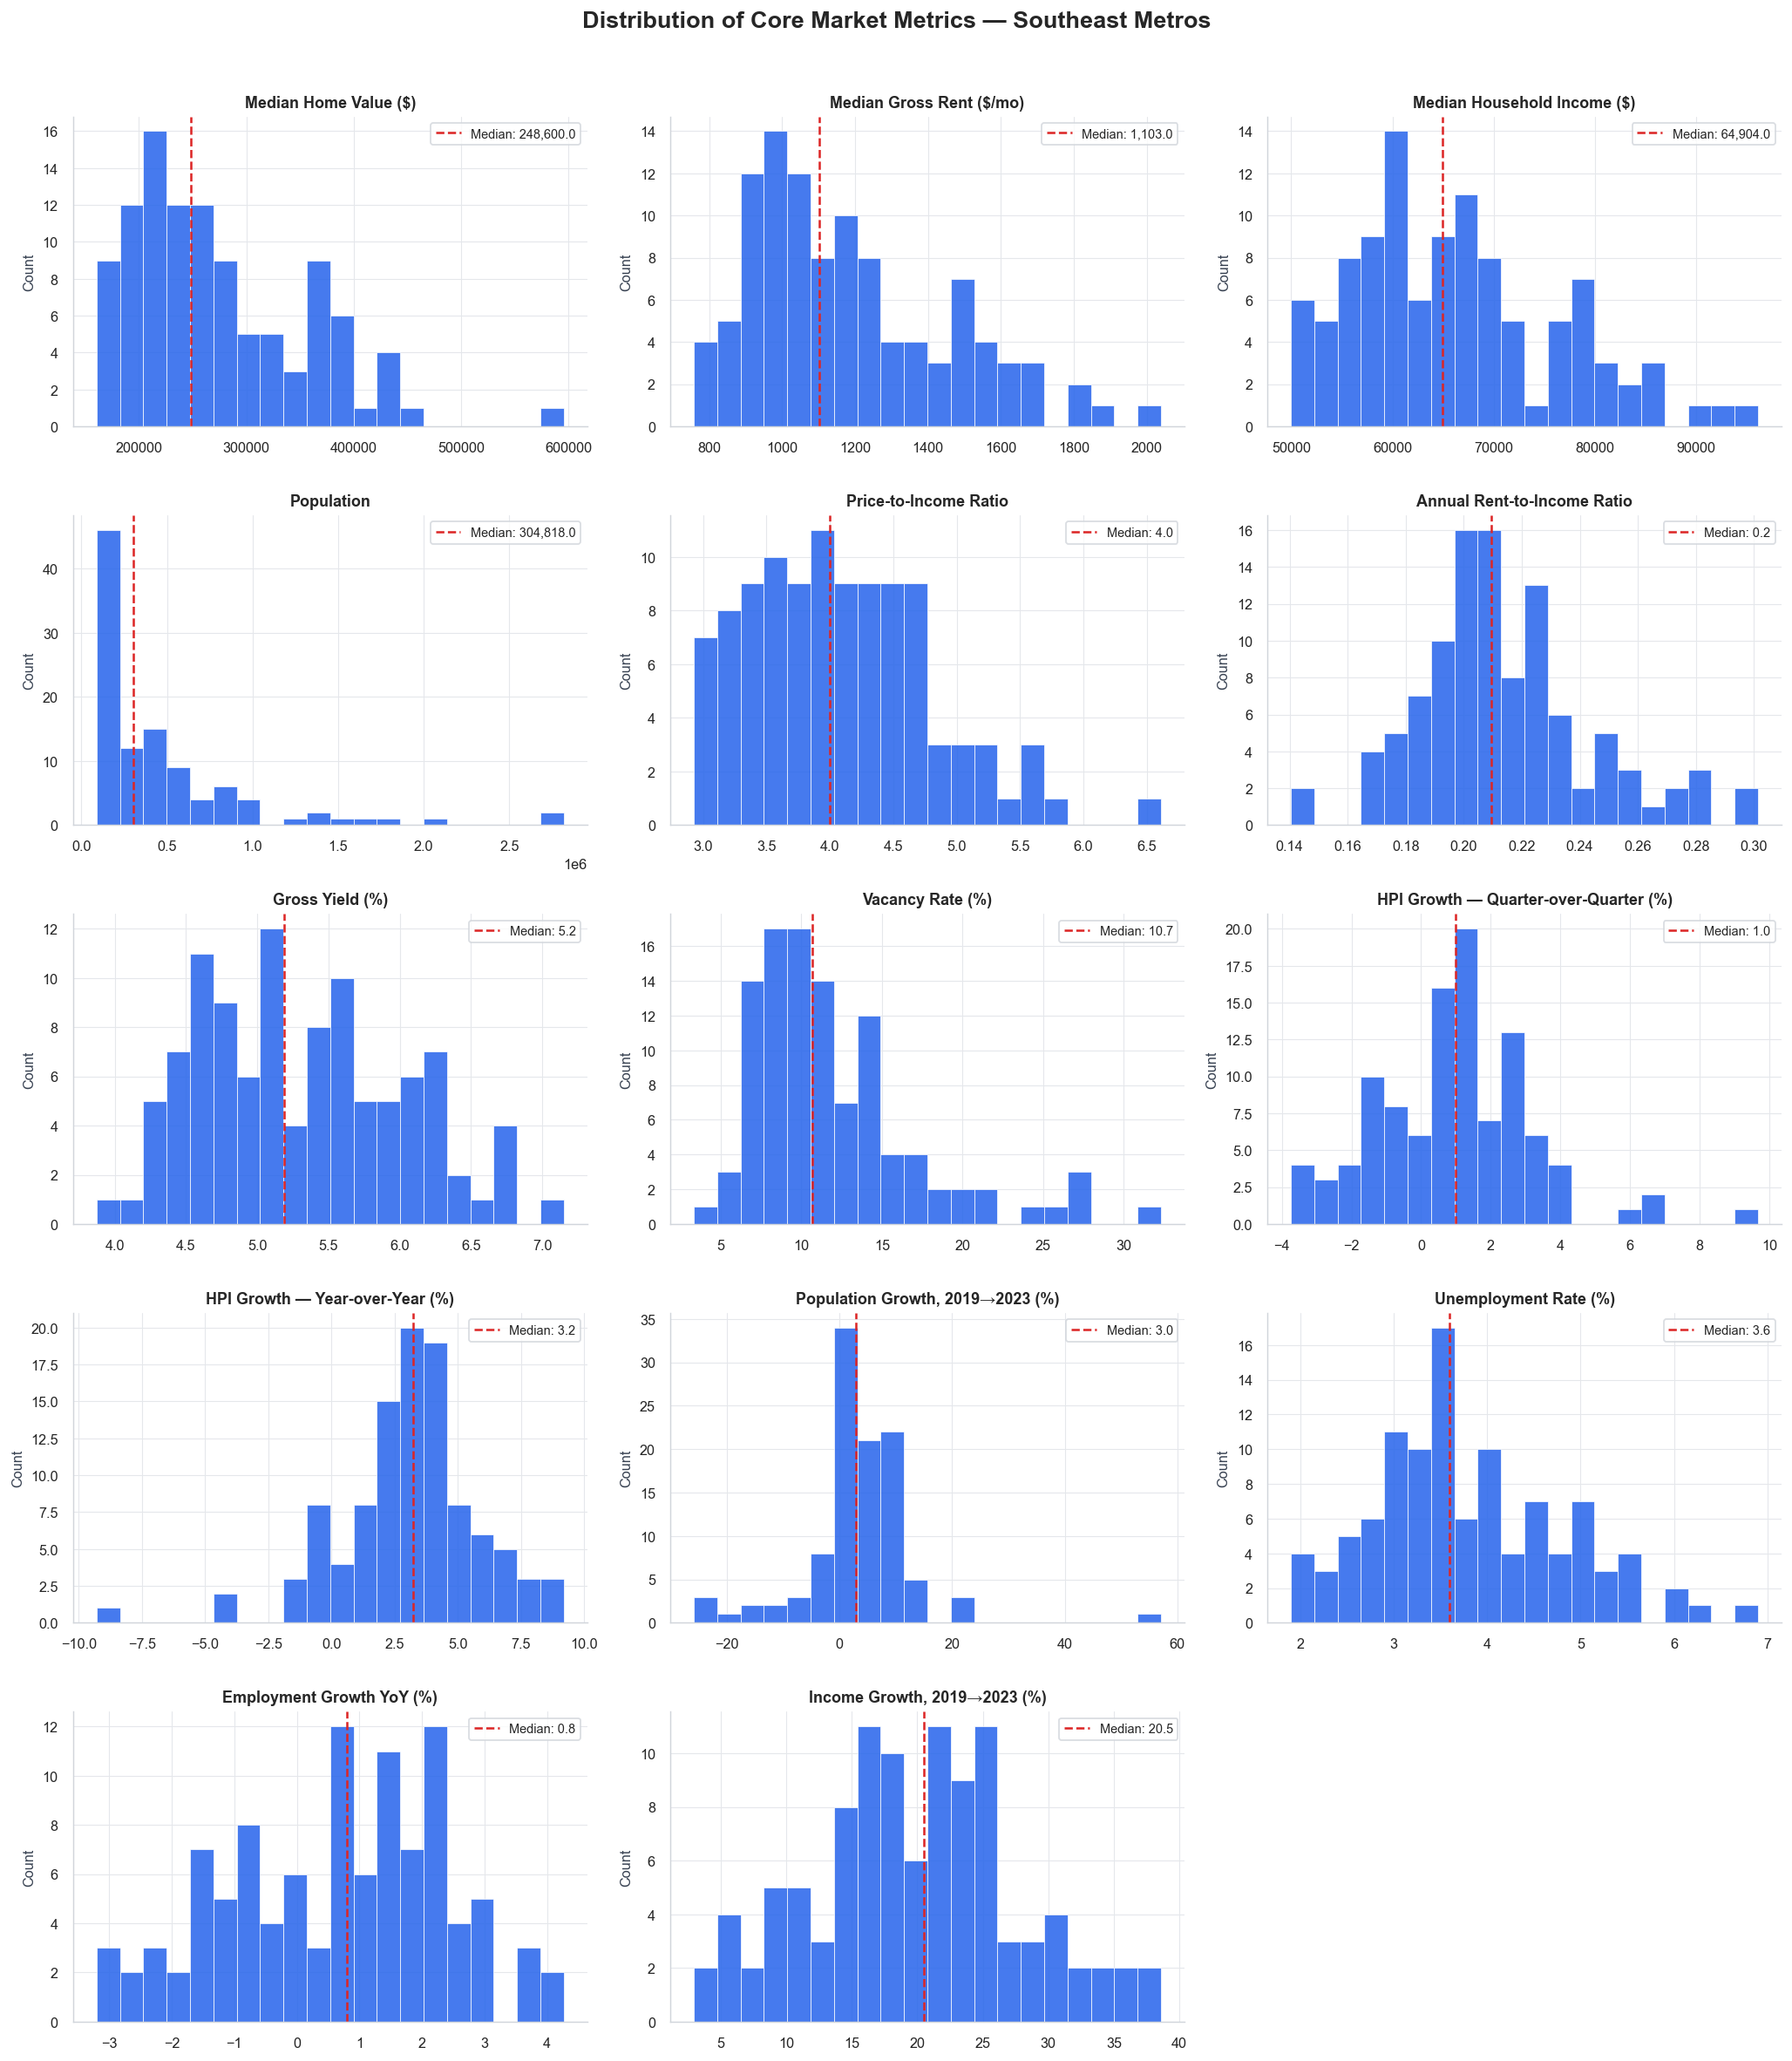

In [10]:
# Distribution of core market metrics — one panel per variable.
# Median line (red dashed) shows where the typical Southeast metro sits.
col_labels = {
    "median_home_value":          "Median Home Value ($)",
    "median_gross_rent":           "Median Gross Rent ($/mo)",
    "median_household_income":     "Median Household Income ($)",
    "population":                 "Population",
    "price_to_income_ratio":       "Price-to-Income Ratio",
    "annual_rent_to_income_ratio": "Annual Rent-to-Income Ratio",
    "gross_yield":                "Gross Yield (%)",
    "vacancy_rate":               "Vacancy Rate (%)",
    "hpi_qoq_pct":               "HPI Growth — Quarter-over-Quarter (%)",
    "hpi_yoy_pct":               "HPI Growth — Year-over-Year (%)",
    "pop_growth_pct":             "Population Growth, 2019→2023 (%)",
    "unemployment_rate":          "Unemployment Rate (%)",
    "employment_yoy_growth_pct":  "Employment Growth YoY (%)",
    "income_growth_pct":          "Income Growth, 2019→2023 (%)",
}

ncols = 3
nrows = -(-len(eda_columns) // ncols)  # ceiling division
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.6))
axes = axes.flatten()

for i, col in enumerate(eda_columns):
    ax = axes[i]
    data = analysis_df[col].dropna()
    sns.histplot(data, bins=20, ax=ax, color=BLUE, alpha=0.85,
                 edgecolor="white", linewidth=0.4)
    ax.axvline(data.median(), color=RED, linestyle="--",
               linewidth=1.4, label=f"Median: {data.median():,.1f}")
    ax.set_title(col_labels.get(col, col), fontsize=10, fontweight="bold", pad=6)
    ax.set_xlabel("")
    ax.set_ylabel("Count", fontsize=9)
    ax.legend(fontsize=8, framealpha=0.8)

for j in range(len(eda_columns), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Distribution of Core Market Metrics — Southeast Metros",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


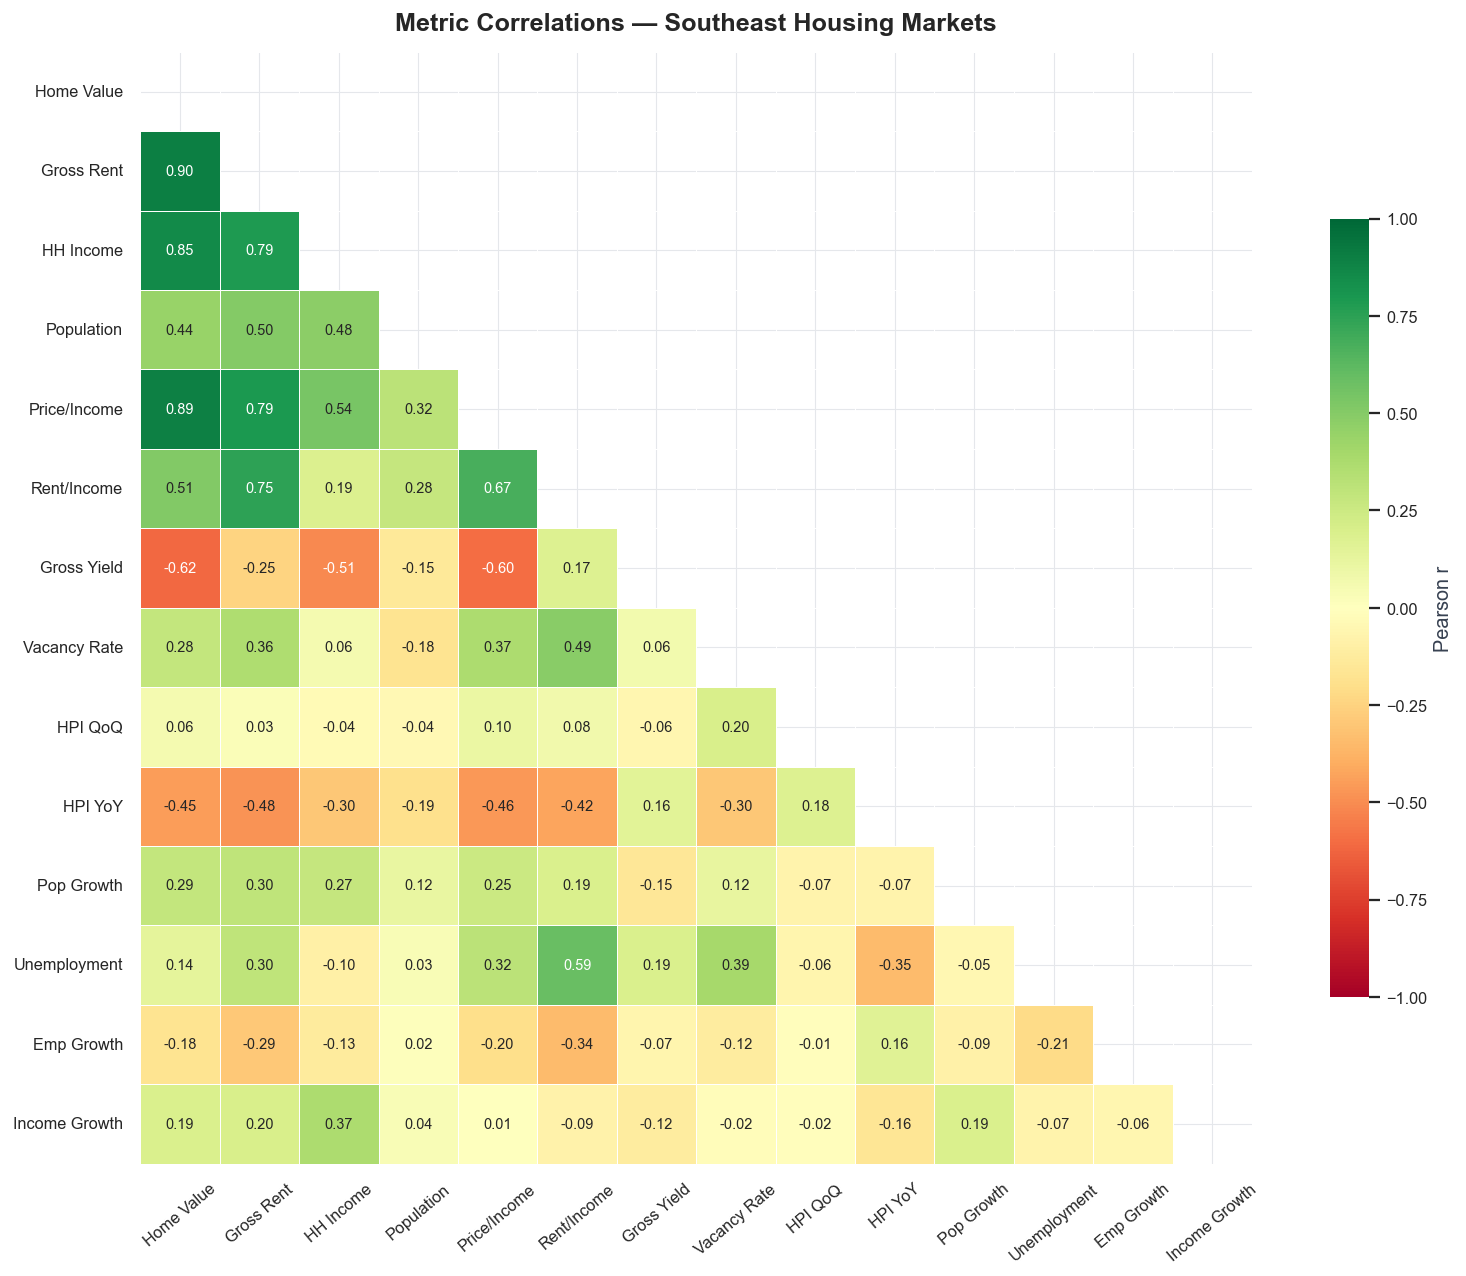

In [11]:
# Correlation heatmap — lower triangle only to avoid redundancy.
# Strong positive correlations (green) and negative correlations (red)
# reveal which metrics move together across Southeast metros.
short_labels = {
    "median_home_value":          "Home Value",
    "median_gross_rent":           "Gross Rent",
    "median_household_income":     "HH Income",
    "population":                 "Population",
    "price_to_income_ratio":       "Price/Income",
    "annual_rent_to_income_ratio": "Rent/Income",
    "gross_yield":                "Gross Yield",
    "vacancy_rate":               "Vacancy Rate",
    "hpi_qoq_pct":               "HPI QoQ",
    "hpi_yoy_pct":               "HPI YoY",
    "pop_growth_pct":             "Pop Growth",
    "unemployment_rate":          "Unemployment",
    "employment_yoy_growth_pct":  "Emp Growth",
    "income_growth_pct":          "Income Growth",
}

corr = analysis_df[eda_columns].corr(numeric_only=True)
corr.index   = [short_labels.get(c, c) for c in corr.index]
corr.columns = [short_labels.get(c, c) for c in corr.columns]

# Mask upper triangle so each pair appears once.
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.7, "label": "Pearson r"},
    ax=ax,
)
ax.set_title("Metric Correlations — Southeast Housing Markets",
             fontsize=14, fontweight="bold")
ax.tick_params(axis="x", rotation=40, labelsize=9)
ax.tick_params(axis="y", rotation=0,  labelsize=9)
plt.tight_layout()
plt.show()


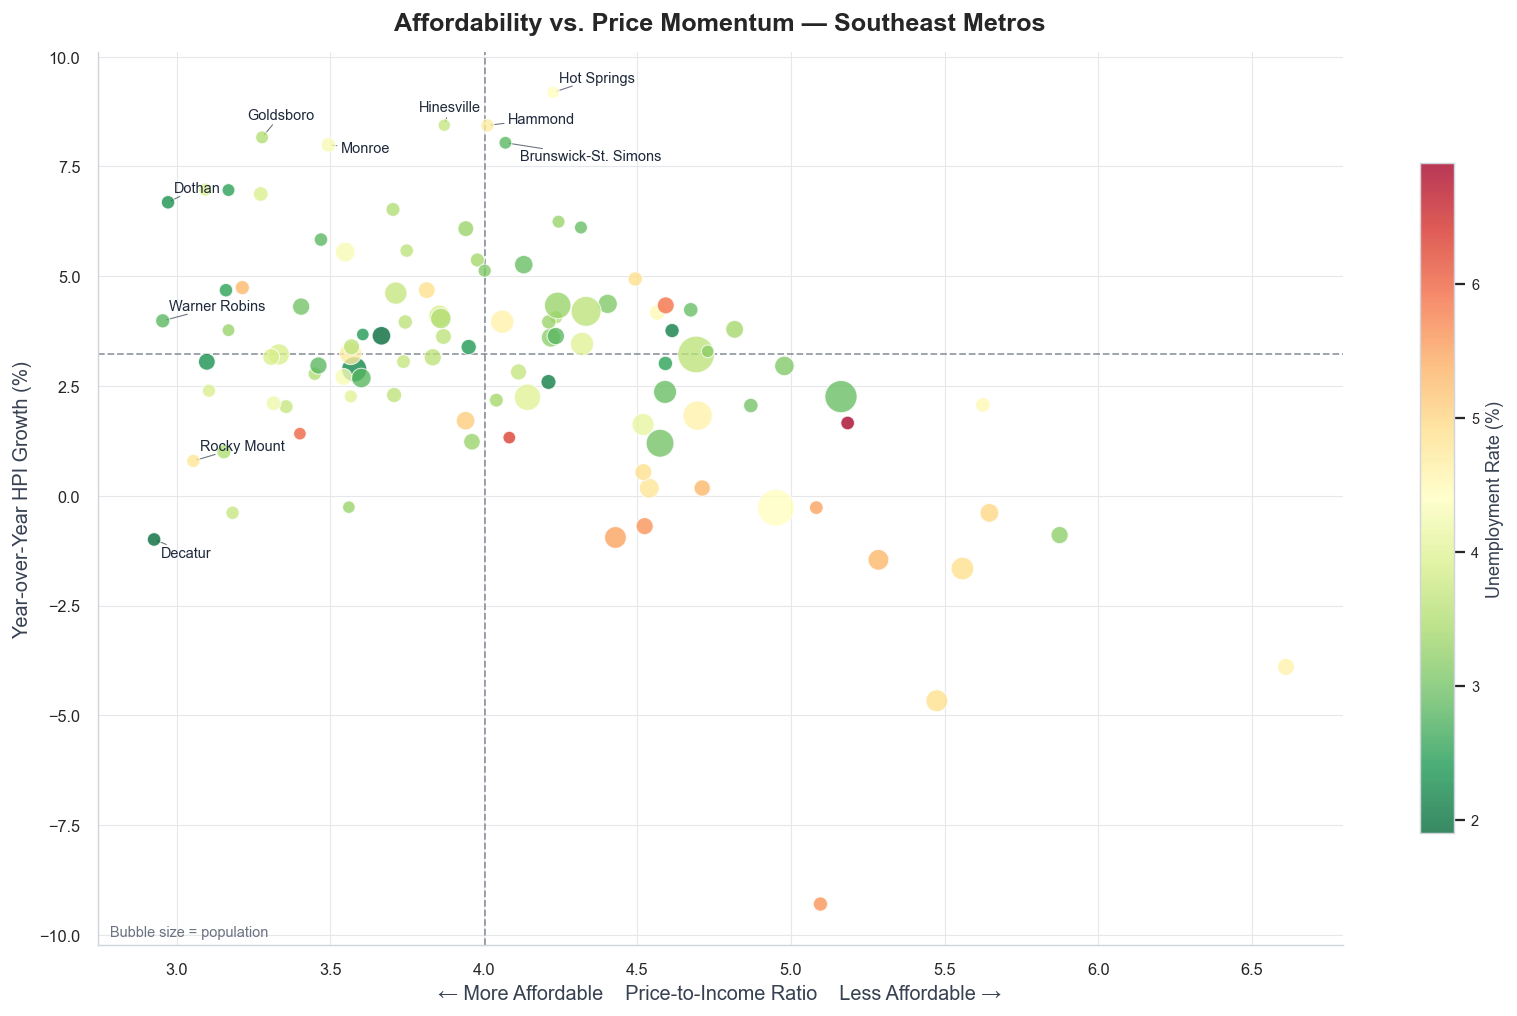

In [12]:
# Affordability vs. price momentum — each bubble is a metro.
# Bubble size = population. Color = unemployment rate (green = lower).
# Dashed lines mark the median on each axis.

fig, ax = plt.subplots(figsize=(13, 8))

scatter = ax.scatter(
    analysis_df["price_to_income_ratio"],
    analysis_df["hpi_yoy_pct"],
    c=analysis_df["unemployment_rate"],
    cmap="RdYlGn_r",
    s=analysis_df["population"] / analysis_df["population"].max() * 380 + 35,
    alpha=0.78,
    edgecolors="white",
    linewidths=0.6,
    zorder=3,
)

# Median reference lines.
med_x = analysis_df["price_to_income_ratio"].median()
med_y = analysis_df["hpi_yoy_pct"].median()
ax.axvline(med_x, color=GRAY, linestyle="--", linewidth=1.0, alpha=0.7, zorder=2)
ax.axhline(med_y, color=GRAY, linestyle="--", linewidth=1.0, alpha=0.7, zorder=2)

# Label top 6 HPI growth metros + 4 most affordable (deduplicated).
label_df = pd.concat([
    analysis_df.nlargest(6, "hpi_yoy_pct"),
    analysis_df.nsmallest(4, "price_to_income_ratio"),
]).drop_duplicates(subset="metro_name")

texts = []
for _, row in label_df.iterrows():
    t = ax.text(
        row["price_to_income_ratio"],
        row["hpi_yoy_pct"],
        row["metro_name"].split(",")[0],
        fontsize=8,
        color="#1e293b",
    )
    texts.append(t)

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", color=GRAY, lw=0.6),
    expand=(1.4, 1.8),
    force_text=(0.4, 0.6),
)

cb = plt.colorbar(scatter, ax=ax, shrink=0.75)
cb.set_label("Unemployment Rate (%)", fontsize=10)
cb.ax.tick_params(labelsize=8)

ax.set_xlabel("← More Affordable    Price-to-Income Ratio    Less Affordable →", fontsize=11)
ax.set_ylabel("Year-over-Year HPI Growth (%)", fontsize=11)
ax.set_title(
    "Affordability vs. Price Momentum — Southeast Metros",
    fontsize=14, fontweight="bold",
)
ax.annotate("Bubble size = population", xy=(0.01, 0.01),
            xycoords="axes fraction", fontsize=8, color=GRAY)
plt.tight_layout()
plt.show()

## 6. Feature Engineering

In [13]:
feature_df = analysis_df.copy()

# --- Affordability ---
feature_df["price_to_income_pctile"] = feature_df["price_to_income_ratio"].rank(pct=True, ascending=False)
feature_df["rent_to_income_pctile"]  = feature_df["annual_rent_to_income_ratio"].rank(pct=True, ascending=False)
feature_df["affordability_score"]    = feature_df[["price_to_income_pctile", "rent_to_income_pctile"]].mean(axis=1)

# --- Growth ---
# Population growth is weighted 40%: the only direct demand signal.
# HPI momentum without population growth is a price anomaly, not a trend.
# Low vacancy (tight supply) supports future price growth.
feature_df["hpi_qoq_pctile"]    = feature_df["hpi_qoq_pct"].rank(pct=True)
feature_df["hpi_yoy_pctile"]    = feature_df["hpi_yoy_pct"].rank(pct=True)
feature_df["pop_growth_pctile"] = feature_df["pop_growth_pct"].rank(pct=True)
feature_df["vacancy_pctile"]    = feature_df["vacancy_rate"].rank(pct=True, ascending=False)
feature_df["growth_score"] = (
    feature_df["hpi_qoq_pctile"]    * 0.20
    + feature_df["hpi_yoy_pctile"]    * 0.20
    + feature_df["pop_growth_pctile"] * 0.40
    + feature_df["vacancy_pctile"]    * 0.20
)

# --- Labor market ---
# E/Pop ratio is the primary signal: unlike the unemployment rate it cannot
# be gamed by labor-force shrinkage — if people leave a metro, E/Pop falls
# even if unemployment stays low.
# Income level is included alongside income growth to prevent a large
# percentage gain from a very low base from looking like genuine strength.
feature_df["employment_pop_pctile"]    = feature_df["employment_pop_ratio"].rank(pct=True)
feature_df["unemployment_pctile"]      = feature_df["unemployment_rate"].rank(pct=True, ascending=False)
feature_df["employment_growth_pctile"] = feature_df["employment_yoy_growth_pct"].rank(pct=True)
feature_df["income_level_pctile"]      = feature_df["median_household_income"].rank(pct=True)
feature_df["income_growth_pctile"]     = feature_df["income_growth_pct"].rank(pct=True)
feature_df["labor_market_score"] = (
    feature_df["employment_pop_pctile"]    * 0.30
    + feature_df["unemployment_pctile"]      * 0.20
    + feature_df["employment_growth_pctile"] * 0.20
    + feature_df["income_level_pctile"]      * 0.15
    + feature_df["income_growth_pctile"]     * 0.15
)

feature_df[
    ["metro_name", "affordability_score", "growth_score", "labor_market_score",
     "employment_pop_ratio", "pop_growth_pct", "median_household_income"]
].sort_values("labor_market_score", ascending=False).head(20)


,metro_name,affordability_score,growth_score,labor_market_score,employment_pop_ratio,pop_growth_pct,median_household_income
65,"Huntsville, AL",0.80,0.85,0.93,0.53,11.75,84929
40,"Fayetteville-Springdale-Rogers, AR",0.57,0.77,0.89,0.53,10.11,77695
99,"Nashville-Davidson--Murfreesboro--Franklin, TN",0.21,0.68,0.87,0.55,8.81,84685
34,"Decatur, AL",1.00,0.46,0.84,0.48,3.95,72956
37,"Durham-Chapel Hill, NC",0.24,0.40,0.81,0.52,-5.51,83280
22,"Chattanooga, TN-GA",0.42,0.54,0.79,0.50,2.51,68677
20,"Charlotte-Concord-Gastonia, NC-SC",0.25,0.62,0.78,0.52,6.38,81262
75,"Knoxville, TN",0.43,0.58,0.78,0.48,8.91,69872
82,"Lexington-Fayette, KY",0.62,0.57,0.77,0.52,0.58,70027
120,"Raleigh-Cary, NC",0.44,0.59,0.76,0.55,8.52,96096


## 7. Methodology and Scoring

In [14]:
# Overall attractiveness score: approximately equal weight across all three pillars.
# This directly answers the first part of the research question.
feature_df["overall_score"] = (
    feature_df["affordability_score"] * 0.33
    + feature_df["growth_score"] * 0.34
    + feature_df["labor_market_score"] * 0.33
)
feature_df["overall_rank"] = feature_df["overall_score"].rank(method="dense", ascending=False)

# Balance score: geometric mean of growth and labor-market scores.
# The geometric mean rewards metros that are strong on both dimensions simultaneously.
# A metro with growth=0.9 and labor_market=0.3 scores sqrt(0.27)=0.52.
# A metro with growth=0.7 and labor_market=0.7 scores sqrt(0.49)=0.70.
# Markets that are lopsided get penalized even if their average looks decent.
feature_df["balance_score"] = (
    feature_df["growth_score"] * feature_df["labor_market_score"]
) ** 0.5
feature_df["balance_rank"] = feature_df["balance_score"].rank(method="dense", ascending=False)

# Reviewed the scoring outputs.
feature_df[
    [
        "metro_name",
        "affordability_score",
        "growth_score",
        "labor_market_score",
        "overall_score",
        "overall_rank",
        "balance_score",
        "balance_rank",
    ]
].sort_values(["overall_rank", "metro_name"])

,metro_name,affordability_score,growth_score,labor_market_score,overall_score,overall_rank,balance_score,balance_rank
65,"Huntsville, AL",0.80,0.85,0.93,0.86,1.00,0.88,1.00
42,"Florence-Muscle Shoals, AL",0.96,0.70,0.68,0.78,2.00,0.69,7.00
34,"Decatur, AL",1.00,0.46,0.84,0.76,3.00,0.62,20.00
40,"Fayetteville-Springdale-Rogers, AR",0.57,0.77,0.89,0.74,4.00,0.83,2.00
15,"Bowling Green, KY",0.70,0.84,0.57,0.70,5.00,0.69,6.00
...,...,...,...,...,...,...,...,...
18,"Cape Coral-Fort Myers, FL",0.03,0.48,0.34,0.29,101.00,0.40,80.00
118,"Port St. Lucie, FL",0.02,0.54,0.28,0.28,102.00,0.39,82.00
105,"Ocala, FL",0.15,0.50,0.19,0.28,103.00,0.31,99.00
131,"Sebring, FL",0.29,0.38,0.03,0.23,104.00,0.10,105.00


### 7a. Sensitivity Check

This check reruns the overall ranking under several alternative pillar-weight schemes to see whether the top metros remain near the top when priorities shift.

In [15]:
# Tested whether the top-ranked metros stay near the top when the pillar weights shift.
weight_scenarios = {
    "Baseline": {"affordability": 0.33, "growth": 0.34, "labor_market": 0.33},
    "Affordability-led": {"affordability": 0.45, "growth": 0.25, "labor_market": 0.30},
    "Growth-led": {"affordability": 0.20, "growth": 0.50, "labor_market": 0.30},
    "Labor-led": {"affordability": 0.25, "growth": 0.25, "labor_market": 0.50},
}

scenario_rank_frames = []
top_5_records = []

for scenario_name, weights in weight_scenarios.items():
    scenario_df = feature_df[[
        "metro_name",
        "affordability_score",
        "growth_score",
        "labor_market_score",
    ]].copy()
    scenario_df["scenario_score"] = (
        scenario_df["affordability_score"] * weights["affordability"]
        + scenario_df["growth_score"] * weights["growth"]
        + scenario_df["labor_market_score"] * weights["labor_market"]
    )
    scenario_df["scenario_rank"] = scenario_df["scenario_score"].rank(method="dense", ascending=False)
    scenario_df["scenario"] = scenario_name

    scenario_rank_frames.append(
        scenario_df[["metro_name", "scenario", "scenario_score", "scenario_rank"]]
    )

    top_5 = scenario_df.sort_values(["scenario_rank", "metro_name"]).head(5)
    for _, row in top_5.iterrows():
        top_5_records.append(
            {
                "scenario": scenario_name,
                "metro_name": row["metro_name"],
                "scenario_rank": row["scenario_rank"],
            }
        )

sensitivity_long_df = pd.concat(scenario_rank_frames, ignore_index=True)
sensitivity_rank_wide = sensitivity_long_df.pivot(
    index="metro_name",
    columns="scenario",
    values="scenario_rank",
)

top_5_frequency = (
    pd.DataFrame(top_5_records)
    .groupby("metro_name")
    .size()
    .rename("top_5_frequency")
)

sensitivity_summary_df = (
    sensitivity_rank_wide
    .assign(
        best_rank=sensitivity_rank_wide.min(axis=1),
        worst_rank=sensitivity_rank_wide.max(axis=1),
        rank_range=sensitivity_rank_wide.max(axis=1) - sensitivity_rank_wide.min(axis=1),
    )
    .join(top_5_frequency, how="left")
    .fillna({"top_5_frequency": 0})
    .reset_index()
)

sensitivity_summary_df["top_5_frequency"] = sensitivity_summary_df["top_5_frequency"].astype(int)

sensitivity_summary_df[
    [
        "metro_name",
        "Baseline",
        "Affordability-led",
        "Growth-led",
        "Labor-led",
        "best_rank",
        "worst_rank",
        "rank_range",
        "top_5_frequency",
    ]
].sort_values(["top_5_frequency", "best_rank", "metro_name"], ascending=[False, True, True]).head(15)

,metro_name,Baseline,Affordability-led,Growth-led,Labor-led,best_rank,worst_rank,rank_range,top_5_frequency
51,"Huntsville, AL",1.00,1.00,1.00,1.00,1.00,1.00,0.00,4
31,"Fayetteville-Springdale-Rogers, AR",4.00,5.00,2.00,3.00,2.00,5.00,3.00,4
33,"Florence-Muscle Shoals, AL",2.00,3.00,3.00,4.00,2.00,4.00,2.00,4
25,"Decatur, AL",3.00,2.00,6.00,2.00,2.00,6.00,4.00,3
10,"Bowling Green, KY",5.00,7.00,4.00,7.00,4.00,7.00,3.00,2
102,"Warner Robins, GA",6.00,4.00,9.00,8.00,4.00,9.00,5.00,1
8,"Birmingham, AL",7.00,9.00,8.00,5.00,5.00,9.00,4.00,1
95,"Spartanburg, SC",9.00,16.00,5.00,22.00,5.00,22.00,17.00,1
63,"Lexington-Fayette, KY",10.00,15.00,11.00,6.00,6.00,15.00,9.00,0
70,"Montgomery, AL",8.00,6.00,13.00,10.00,6.00,13.00,7.00,0


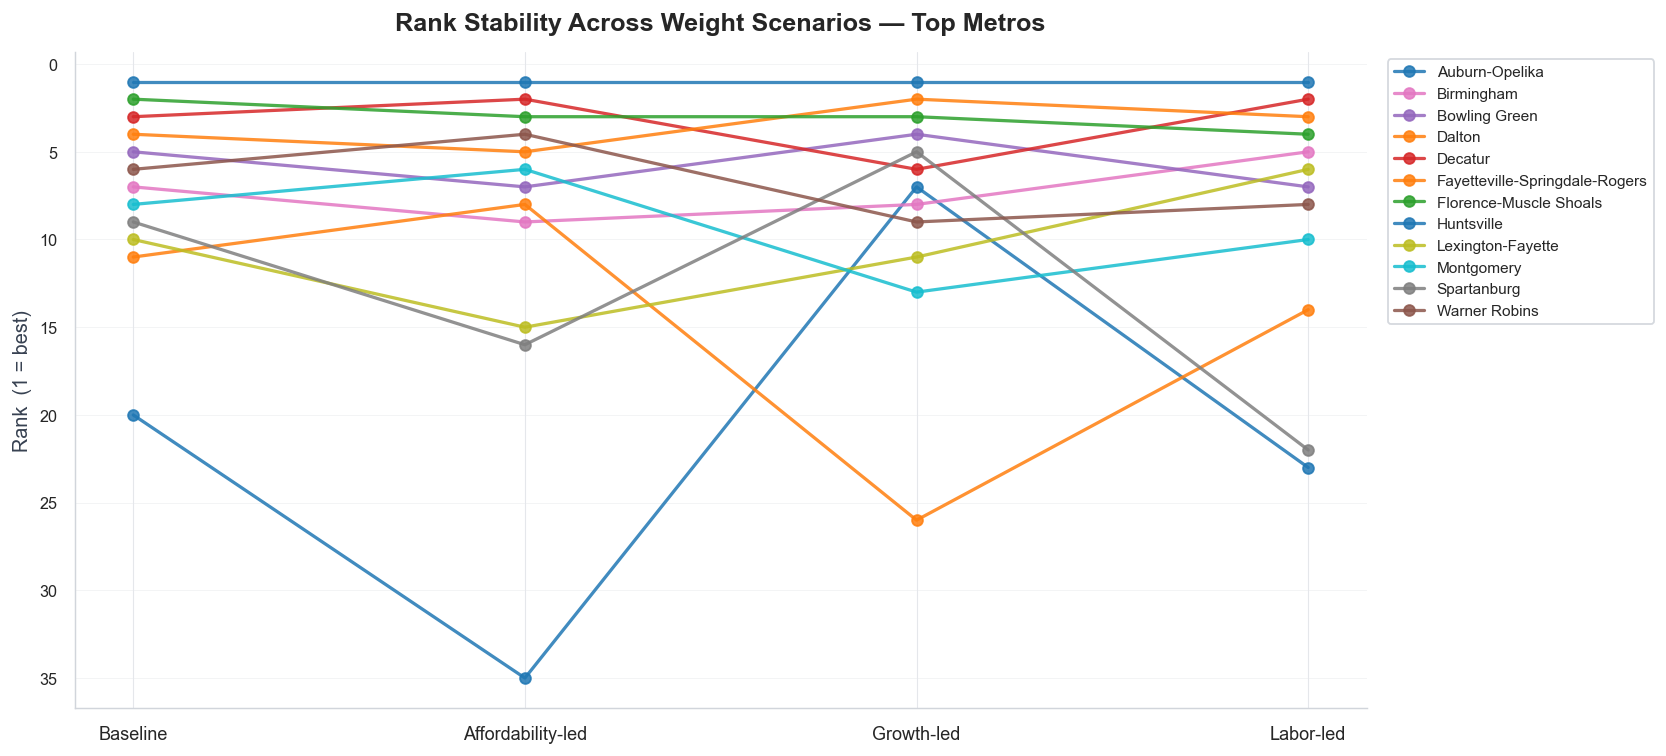

Metros in the top 5 across 3 or more weight scenarios:
                            metro_name  Baseline  Affordability-led  \
51                      Huntsville, AL      1.00               1.00   
25                         Decatur, AL      3.00               2.00   
31  Fayetteville-Springdale-Rogers, AR      4.00               5.00   
33          Florence-Muscle Shoals, AL      2.00               3.00   

    Growth-led  Labor-led  top_5_frequency  
51        1.00       1.00                4  
25        6.00       2.00                3  
31        2.00       3.00                4  
33        3.00       4.00                4  


In [16]:
# Rank-stability chart: shows how each metro's rank shifts across the four weight scenarios.
# A narrow band = the metro's position is robust to weight changes.
# A wide band = the metro's rank depends heavily on which pillar is prioritised.

top_metros = (
    sensitivity_summary_df
    .sort_values(["top_5_frequency", "best_rank"], ascending=[False, True])
    .head(12)["metro_name"]
    .tolist()
)

scenarios = ["Baseline", "Affordability-led", "Growth-led", "Labor-led"]
plot_df = sensitivity_long_df[sensitivity_long_df["metro_name"].isin(top_metros)].copy()
plot_df["metro_short"] = plot_df["metro_name"].str.split(",").str[0]

fig, ax = plt.subplots(figsize=(13, 6))

palette = sns.color_palette("tab10", n_colors=len(top_metros))
color_map = {m.split(",")[0]: c for m, c in zip(top_metros, palette)}

for metro, group in plot_df.groupby("metro_short"):
    group = group.set_index("scenario").reindex(scenarios)
    ax.plot(scenarios, group["scenario_rank"], marker="o", linewidth=1.8,
            color=color_map[metro], alpha=0.85, label=metro)

ax.invert_yaxis()
ax.set_ylabel("Rank  (1 = best)", fontsize=11)
ax.set_xlabel("")
ax.set_title("Rank Stability Across Weight Scenarios — Top Metros", fontsize=14, fontweight="bold")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8.5, framealpha=0.9)
ax.tick_params(axis="x", labelsize=10)
ax.grid(axis="y", linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

# Summary: metros that stay in the top 5 across multiple scenarios are the most defensible picks.
stable = sensitivity_summary_df[sensitivity_summary_df["top_5_frequency"] >= 3].sort_values("best_rank")
print("Metros in the top 5 across 3 or more weight scenarios:")
print(stable[["metro_name", "Baseline", "Affordability-led", "Growth-led", "Labor-led", "top_5_frequency"]])

## 8. Market Ranking

In [17]:
# Segmented markets into simple score tiers to make the final recommendations easier to discuss.
# These tiers are relative thirds of the final score distribution, not fixed score cutoffs.
feature_df["market_tier"] = pd.qcut(
    feature_df["overall_score"],
    q=3,
    labels=["Lower Tier", "Middle Tier", "Top Tier"],
)

# Ranked the top overall markets — metros with the strongest combined score
# across affordability, growth, and labor-market strength.
top_overall_df = feature_df[
    [
        "overall_rank",
        "metro_name",
        "overall_score",
        "affordability_score",
        "growth_score",
        "labor_market_score",
        "market_tier",
    ]
].sort_values(["overall_rank", "metro_name"])
top_overall_df.head(10)

,overall_rank,metro_name,overall_score,affordability_score,growth_score,labor_market_score,market_tier
65,1.00,"Huntsville, AL",0.86,0.80,0.85,0.93,Top Tier
42,2.00,"Florence-Muscle Shoals, AL",0.78,0.96,0.70,0.68,Top Tier
34,3.00,"Decatur, AL",0.76,1.00,0.46,0.84,Top Tier
40,4.00,"Fayetteville-Springdale-Rogers, AR",0.74,0.57,0.77,0.89,Top Tier
15,5.00,"Bowling Green, KY",0.70,0.70,0.84,0.57,Top Tier
151,6.00,"Warner Robins, GA",0.70,0.94,0.60,0.57,Top Tier
13,7.00,"Birmingham, AL",0.68,0.69,0.61,0.74,Top Tier
92,8.00,"Montgomery, AL",0.67,0.85,0.55,0.60,Top Tier
138,9.00,"Spartanburg, SC",0.65,0.67,0.82,0.47,Top Tier
82,10.00,"Lexington-Fayette, KY",0.65,0.62,0.57,0.77,Top Tier


In [18]:
# Ranked the top balanced markets — metros that score well on both
# growth potential AND labor-market stability, not just one or the other.
top_balance_df = feature_df[
    [
        "balance_rank",
        "metro_name",
        "balance_score",
        "growth_score",
        "labor_market_score",
        "affordability_score",
    ]
].sort_values(["balance_rank", "metro_name"])
top_balance_df.head(10)

,balance_rank,metro_name,balance_score,growth_score,labor_market_score,affordability_score
65,1.00,"Huntsville, AL",0.88,0.85,0.93,0.80
40,2.00,"Fayetteville-Springdale-Rogers, AR",0.83,0.77,0.89,0.57
99,3.00,"Nashville-Davidson--Murfreesboro--Franklin, TN",0.77,0.68,0.87,0.21
20,4.00,"Charlotte-Concord-Gastonia, NC-SC",0.70,0.62,0.78,0.25
10,5.00,"Auburn-Opelika, AL",0.70,0.80,0.60,0.41
15,6.00,"Bowling Green, KY",0.69,0.84,0.57,0.70
42,7.00,"Florence-Muscle Shoals, AL",0.69,0.70,0.68,0.96
48,8.00,"Gainesville, GA",0.68,0.65,0.71,0.36
13,9.00,"Birmingham, AL",0.67,0.61,0.74,0.69
75,10.00,"Knoxville, TN",0.67,0.58,0.78,0.43


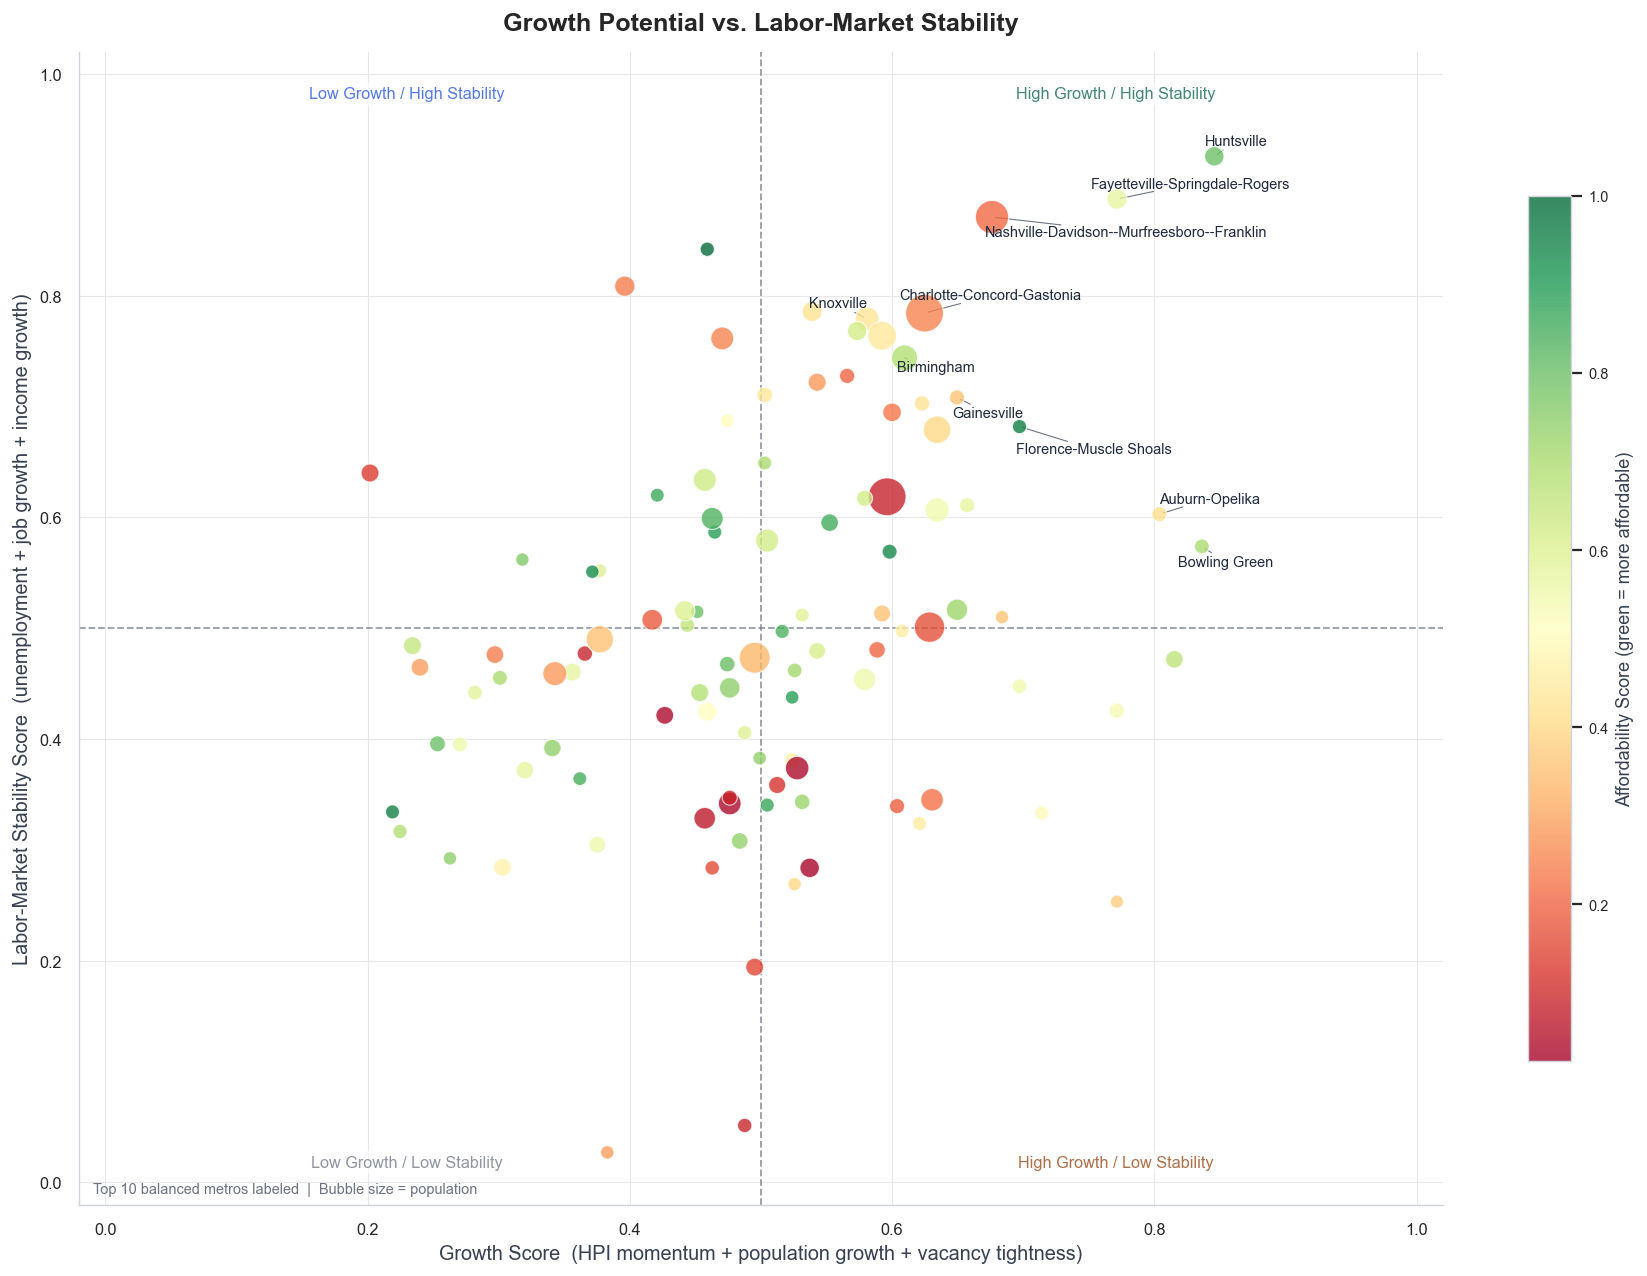

In [19]:
# Scatter plot of growth potential vs. labor-market stability.
# This directly answers the second part of the research question:
# which metros best balance the two dimensions.
# The upper-right quadrant is the sweet spot: high growth AND high stability.

fig, ax = plt.subplots(figsize=(14, 10))

scatter = ax.scatter(
    feature_df["growth_score"],
    feature_df["labor_market_score"],
    c=feature_df["affordability_score"],
    cmap="RdYlGn",
    s=feature_df["population"] / feature_df["population"].max() * 400 + 40,
    alpha=0.78,
    edgecolors="white",
    linewidths=0.6,
    zorder=3,
)

# Quadrant reference lines at 0.5 on both axes.
ax.axvline(x=0.5, color=GRAY, linestyle="--", linewidth=1.0, alpha=0.7, zorder=2)
ax.axhline(y=0.5, color=GRAY, linestyle="--", linewidth=1.0, alpha=0.7, zorder=2)

# Quadrant labels — shared style dict to avoid repetition.
_ql = dict(fontsize=9, ha="center", alpha=0.75,
           bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.6))
ax.text(0.76, 0.97, "High Growth / High Stability", transform=ax.transAxes, va="top",    color="#065f46", **_ql)
ax.text(0.24, 0.97, "Low Growth / High Stability",  transform=ax.transAxes, va="top",    color="#1d4ed8", **_ql)
ax.text(0.76, 0.03, "High Growth / Low Stability",  transform=ax.transAxes, va="bottom", color="#92400e", **_ql)
ax.text(0.24, 0.03, "Low Growth / Low Stability",   transform=ax.transAxes, va="bottom", color=GRAY,      **_ql)

# Annotate the top 10 balanced markets by name.
top_label = feature_df.nsmallest(10, "balance_rank")
texts = [
    ax.text(row["growth_score"], row["labor_market_score"],
            row["metro_name"].split(",")[0], fontsize=8, color="#1e293b")
    for _, row in top_label.iterrows()
]
adjust_text(texts, ax=ax,
            arrowprops=dict(arrowstyle="-", color=GRAY, lw=0.6),
            expand=(1.5, 2.0), force_text=(0.5, 0.8))

cb = plt.colorbar(scatter, ax=ax, shrink=0.75)
cb.set_label("Affordability Score (green = more affordable)", fontsize=10)
cb.ax.tick_params(labelsize=8)

ax.set_xlabel("Growth Score  (HPI momentum + population growth + vacancy tightness)", fontsize=11)
ax.set_ylabel("Labor-Market Stability Score  (unemployment + job growth + income growth)", fontsize=11)
ax.set_title("Growth Potential vs. Labor-Market Stability", fontsize=14, fontweight="bold")
ax.annotate("Top 10 balanced metros labeled  |  Bubble size = population",
            xy=(0.01, 0.01), xycoords="axes fraction", fontsize=8, color=GRAY)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
plt.tight_layout()
plt.show()

## 9. Findings and Recommendations

The analysis addresses the research question in two parts.

On overall attractiveness, the top-ranked metros are those that score consistently across affordability, income growth, employment strength, and home-price momentum. Alabama metros dominate this view because they combine genuinely low price-to-income ratios with solid labor markets. Huntsville is the standout within that group — it has a strong economic base (defense and aerospace), real population growth, and the lowest unemployment in the sample. Florence-Muscle Shoals scores highest on affordability but carries a weaker growth signal, which the approximately equal-weight scoring still rewards.

On the balance between growth potential and labor-market stability, the picture changes. The balance score uses the geometric mean of the two pillar scores, which explicitly penalizes markets that are strong on one dimension but weak on the other. Markets that appear in both the overall top 10 and the balance top 10 are the most defensible picks — they are not just cheap or just fast-growing, but genuinely solid on both axes. The scatter plot makes this tradeoff visible: metros in the upper-right quadrant have both high growth scores and high labor-market stability, and those are the markets that most directly answer the second half of the research question.

The key takeaway is that the top overall markets and the top balanced markets overlap substantially but not completely. Some metros rank well overall because affordability carries them despite weak growth. Those same markets drop in the balance ranking, which only rewards genuine two-dimensional strength.

### Stakeholder Implications

The rankings answer a different question depending on who is reading them.

**Homebuyer** — Florence-Muscle Shoals and Decatur lead on raw affordability, but Huntsville is the stronger all-around pick: it adds population growth and a tighter labor market to a still-affordable price base. Buyers who prioritize price over growth should look at the high-affordability end of the overall ranking; buyers who want appreciation upside alongside stability should focus on the balance top five.

**Real estate investor** — Huntsville and Fayetteville-Springdale-Rogers score highest on both growth momentum and labor-market strength, which reduces the risk that price appreciation is driven by speculation rather than underlying demand. Auburn-Opelika also appears in the balance top five on strong employment growth and a university anchor. Markets with high growth scores but weaker labor-market scores (upper-left in the scatter plot) carry more cyclical risk.

**Lender or risk analyst** — Metros with high Employment-to-Population ratios and income growth signal lower default risk than those that appear affordable only because of population stagnation. Huntsville, Fayetteville-Springdale-Rogers, and Nashville show the strongest combination of income growth and employment depth. Markets that rank high on affordability but low on labor market strength should be underwritten more conservatively.

**Regional planner or economic developer** — Charlotte and Nashville represent the upper bound of what balanced growth looks like at scale in the Southeast; both carry affordability headwinds from rapid appreciation but maintain broad employment bases. Mid-size metros like Bowling Green, KY and Spartanburg, SC demonstrate that manufacturing and institutional anchors can sustain labor-market strength even without the population growth of larger metros.


### Recommended Actions

Based on the rankings, here is what a stakeholder should actually do with this analysis:

**If you are a homebuyer entering the Southeast market** — shortlist Huntsville, AL first. It scores in the top tier on all three pillars simultaneously, meaning you are not trading affordability for growth or vice versa. If you need maximum price-entry flexibility and are willing to accept slower appreciation, add Florence-Muscle Shoals and Decatur to your shortlist. Use the balance top five when you want a cleaner read on which metros look resilient rather than simply inexpensive.

**If you are a real estate investor underwriting a new position** — Huntsville and Fayetteville-Springdale-Rogers (AR) are the two markets where both price momentum and labor-market depth are simultaneously high. That combination reduces the risk that appreciation is speculative rather than demand-driven. Do not rely solely on the balance score; cross-reference with local cap rate data and rental vacancy before committing.

**If you are a lender or risk analyst setting market-level underwriting guidelines** — treat the labor-market score as the primary credit-quality signal. Markets with E/Pop ratios and income growth in the top quartile (Huntsville, Fayetteville-Springdale-Rogers, Nashville) warrant more favorable LTV treatment than markets where affordability is high only because prices stagnated. Flag markets with high affordability scores but low balance scores as potentially fragile demand environments.

**If you are a regional economic development official** — the balance score top five (Huntsville, Fayetteville-Springdale-Rogers, Nashville, Charlotte, Auburn-Opelika) are the benchmark comps for what sustained, balanced growth looks like in the Southeast. Markets currently outside the top tier should examine which pillar is holding them back: growth, labor market, or affordability. That gap is the policy lever.

**What this analysis does not replace:** This is a screening tool, not a due-diligence substitute. Rankings are point-in-time and based on publicly available macro data. Before any capital decision, validate with current on-the-ground data — active listings, days on market, local employer news, and current local market conditions.


In [20]:
# Summarized the top markets across both dimensions of the research question.
top_5_overall = top_overall_df.head(5).copy()
top_5_balanced = top_balance_df.head(5).copy()

print("Top 5 overall markets (affordability + growth + labor market):")
print(top_5_overall[["overall_rank", "metro_name", "overall_score", "market_tier"]])

print("\nTop 5 balanced markets (strongest on both growth AND stability):")
print(top_5_balanced[["balance_rank", "metro_name", "balance_score", "growth_score", "labor_market_score"]])

# Built a concise recommendation table showing all four key scores.
recommendation_df = feature_df[
    [
        "metro_name",
        "market_tier",
        "overall_rank",
        "balance_rank",
        "affordability_score",
        "growth_score",
        "labor_market_score",
    ]
].sort_values(["overall_rank", "metro_name"])

recommendation_df.head(15)

Top 5 overall markets (affordability + growth + labor market):
    overall_rank                          metro_name  overall_score  \
65          1.00                      Huntsville, AL           0.86   
42          2.00          Florence-Muscle Shoals, AL           0.78   
34          3.00                         Decatur, AL           0.76   
40          4.00  Fayetteville-Springdale-Rogers, AR           0.74   
15          5.00                   Bowling Green, KY           0.70   

   market_tier  
65    Top Tier  
42    Top Tier  
34    Top Tier  
40    Top Tier  
15    Top Tier  

Top 5 balanced markets (strongest on both growth AND stability):
    balance_rank                                      metro_name  \
65          1.00                                  Huntsville, AL   
40          2.00              Fayetteville-Springdale-Rogers, AR   
99          3.00  Nashville-Davidson--Murfreesboro--Franklin, TN   
20          4.00               Charlotte-Concord-Gastonia, NC-SC   
10

,metro_name,market_tier,overall_rank,balance_rank,affordability_score,growth_score,labor_market_score
65,"Huntsville, AL",Top Tier,1.00,1.00,0.80,0.85,0.93
42,"Florence-Muscle Shoals, AL",Top Tier,2.00,7.00,0.96,0.70,0.68
34,"Decatur, AL",Top Tier,3.00,20.00,1.00,0.46,0.84
40,"Fayetteville-Springdale-Rogers, AR",Top Tier,4.00,2.00,0.57,0.77,0.89
15,"Bowling Green, KY",Top Tier,5.00,6.00,0.70,0.84,0.57
151,"Warner Robins, GA",Top Tier,6.00,28.00,0.94,0.60,0.57
13,"Birmingham, AL",Top Tier,7.00,9.00,0.69,0.61,0.74
92,"Montgomery, AL",Top Tier,8.00,30.00,0.85,0.55,0.60
138,"Spartanburg, SC",Top Tier,9.00,22.00,0.67,0.82,0.47
82,"Lexington-Fayette, KY",Top Tier,10.00,12.00,0.62,0.57,0.77


## 10. Limitations and Next Steps

This analysis has several important limitations.

**Complete-case dropout (156 → 105 metros).** The full Southeast metro universe loaded from Census is 156 metros, but the final scoring dataset uses the 105 metros that have complete coverage across all required metrics. The two primary drivers of dropout are FHFA coverage (49 metros have no usable HPI series) and BLS LAUS coverage (46 metros are missing a current unemployment or employment reading). Those counts overlap, so they do not add linearly to the final dropout total. These gaps reflect the limits of publicly available metro-level data, not data quality failures in the pipeline. Because adjacent ranks within the final 105 reflect real differences in the data, they should still be interpreted as approximate tiers rather than precise ordinal positions.

**ACS 1-year coverage.** The Census metro universe is based on ACS 1-year estimates, which are only published for metros with populations of approximately 65,000 or more. Smaller Southeast markets are not in scope and do not appear in the sample.

**Building permits and industry employment.** The ingestion pipeline includes `fetch_census_building_permits()` and `fetch_bls_industry_employment()` for supply-side and sector-composition context. Building permits now load for 109 metros and can support future supply-side analysis, but they are not used in any current pillar calculation. Industry-employment coverage remains optional and is skipped by default because BLS SAE metro coverage and request limits are inconsistent enough to make it unreliable as a required input.

**Simple weighting and point-in-time snapshot.** The percentile scoring and approximately equal-weight pillars create a transparent ranking, and the sensitivity check above shows the top-tier metros remain stable under alternative weight schemes. Even so, rankings at the margin should be read as approximate rather than precise. The scoring reflects the most recent available data vintage and does not forecast future conditions or account for local policy changes, new employer announcements, or mortgage-rate-driven affordability shifts.

**Next steps** for a stronger version would include resolving the building permits and industry employment data gaps, testing score stability across multiple ACS vintages, adding interest-rate-adjusted affordability, and incorporating sub-market rental vacancy and wage-growth-by-sector data.